<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📦 Installing Required Libraries
</h2>

In [ ]:
!pip install soundata librosa torchvision torchaudio tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.0/162.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 11.2 MB/s eta 0:00:00


In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import librosa
import librosa.display
import soundata

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  ⬇️ UrbanSound8K Dataset
</h2>

In [ ]:
us8k = soundata.initialize('urbansound8k')
us8k.download()
us8k.validate()
print("Dataset ready at:", us8k.data_home)

5.61GB [11:31, 8.72MB/s]                            
1.15MB [00:01, 646kB/s]                             
100%|██████████| 8732/8732 [00:43<00:00, 199.06it/s]

Dataset ready at: /root/sound_datasets/urbansound8k


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📂Audio Files and Metadata
</h2>

In [ ]:
DATA_HOME = Path(us8k.data_home)
AUDIO_DIR = DATA_HOME / "audio"
META_PATH = DATA_HOME / "metadata" / "UrbanSound8K.csv"

meta = pd.read_csv(META_PATH)
print("Metadata rows:", len(meta))
meta.head()

Metadata rows: 8732


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📊 Dataset
</h2>

In [ ]:
durations = meta['end'] - meta['start']

summary = {
    "Total number of clips": len(meta),
    "Number of classes":     meta['classID'].nunique(),
    "Sampling rate (Hz)":    22050,
    "Min clip duration (s)": round(durations.min(), 3),
    "Max clip duration (s)": round(durations.max(), 3),
    "Mean clip duration (s)": round(durations.mean(), 3),
}
for k, v in summary.items():
    print(f"{k:30s}: {v}")

Total number of clips         : 8732
Number of classes             : 10
Sampling rate (Hz)            : 22050
Min clip duration (s)         : 0.055
Max clip duration (s)         : 4.0
Mean clip duration (s)        : 3.608


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📈 Class Distribution
</h2>

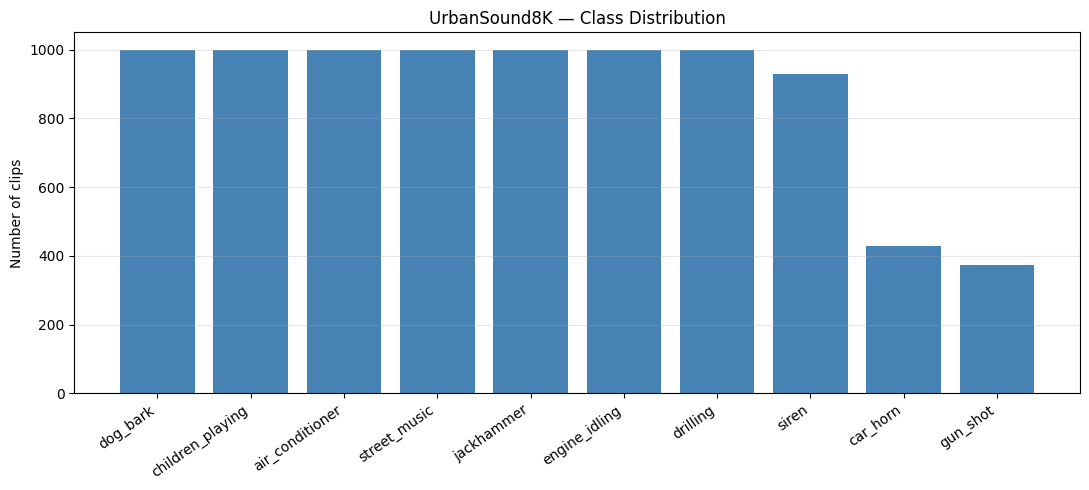


Min class size: 374
Max class size: 1000
Imbalance ratio: 2.67


In [ ]:
class_counts = meta['class'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(class_counts.index, class_counts.values, color='steelblue')
plt.xticks(rotation=35, ha='right')
plt.ylabel("Number of clips")
plt.title("UrbanSound8K — Class Distribution")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMin class size:", class_counts.min())
print("Max class size:", class_counts.max())
print("Imbalance ratio:", round(class_counts.max() / class_counts.min(), 2))

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🛠️ Audio and Spectrogram
</h2>

In [ ]:
SR             = 22050
TARGET_SECONDS = 4
TARGET_LEN     = SR * TARGET_SECONDS
N_MELS         = 64

def load_audio(path, target_len=TARGET_LEN):
    """Load, resample to 22.05 kHz, pad/truncate to fixed length."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

def compute_stft(y, n_fft=1024, hop_length=None):
    """Log-magnitude STFT spectrogram in dB."""
    if hop_length is None:
        hop_length = n_fft // 2
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)

def compute_mel(y, n_fft=1024, hop_length=None, n_mels=N_MELS):
    """Log-mel spectrogram in dB."""
    if hop_length is None:
        hop_length = n_fft // 2
    M = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    return librosa.power_to_db(M, ref=np.max).astype(np.float32)

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🖼️  Sample Spectrograms

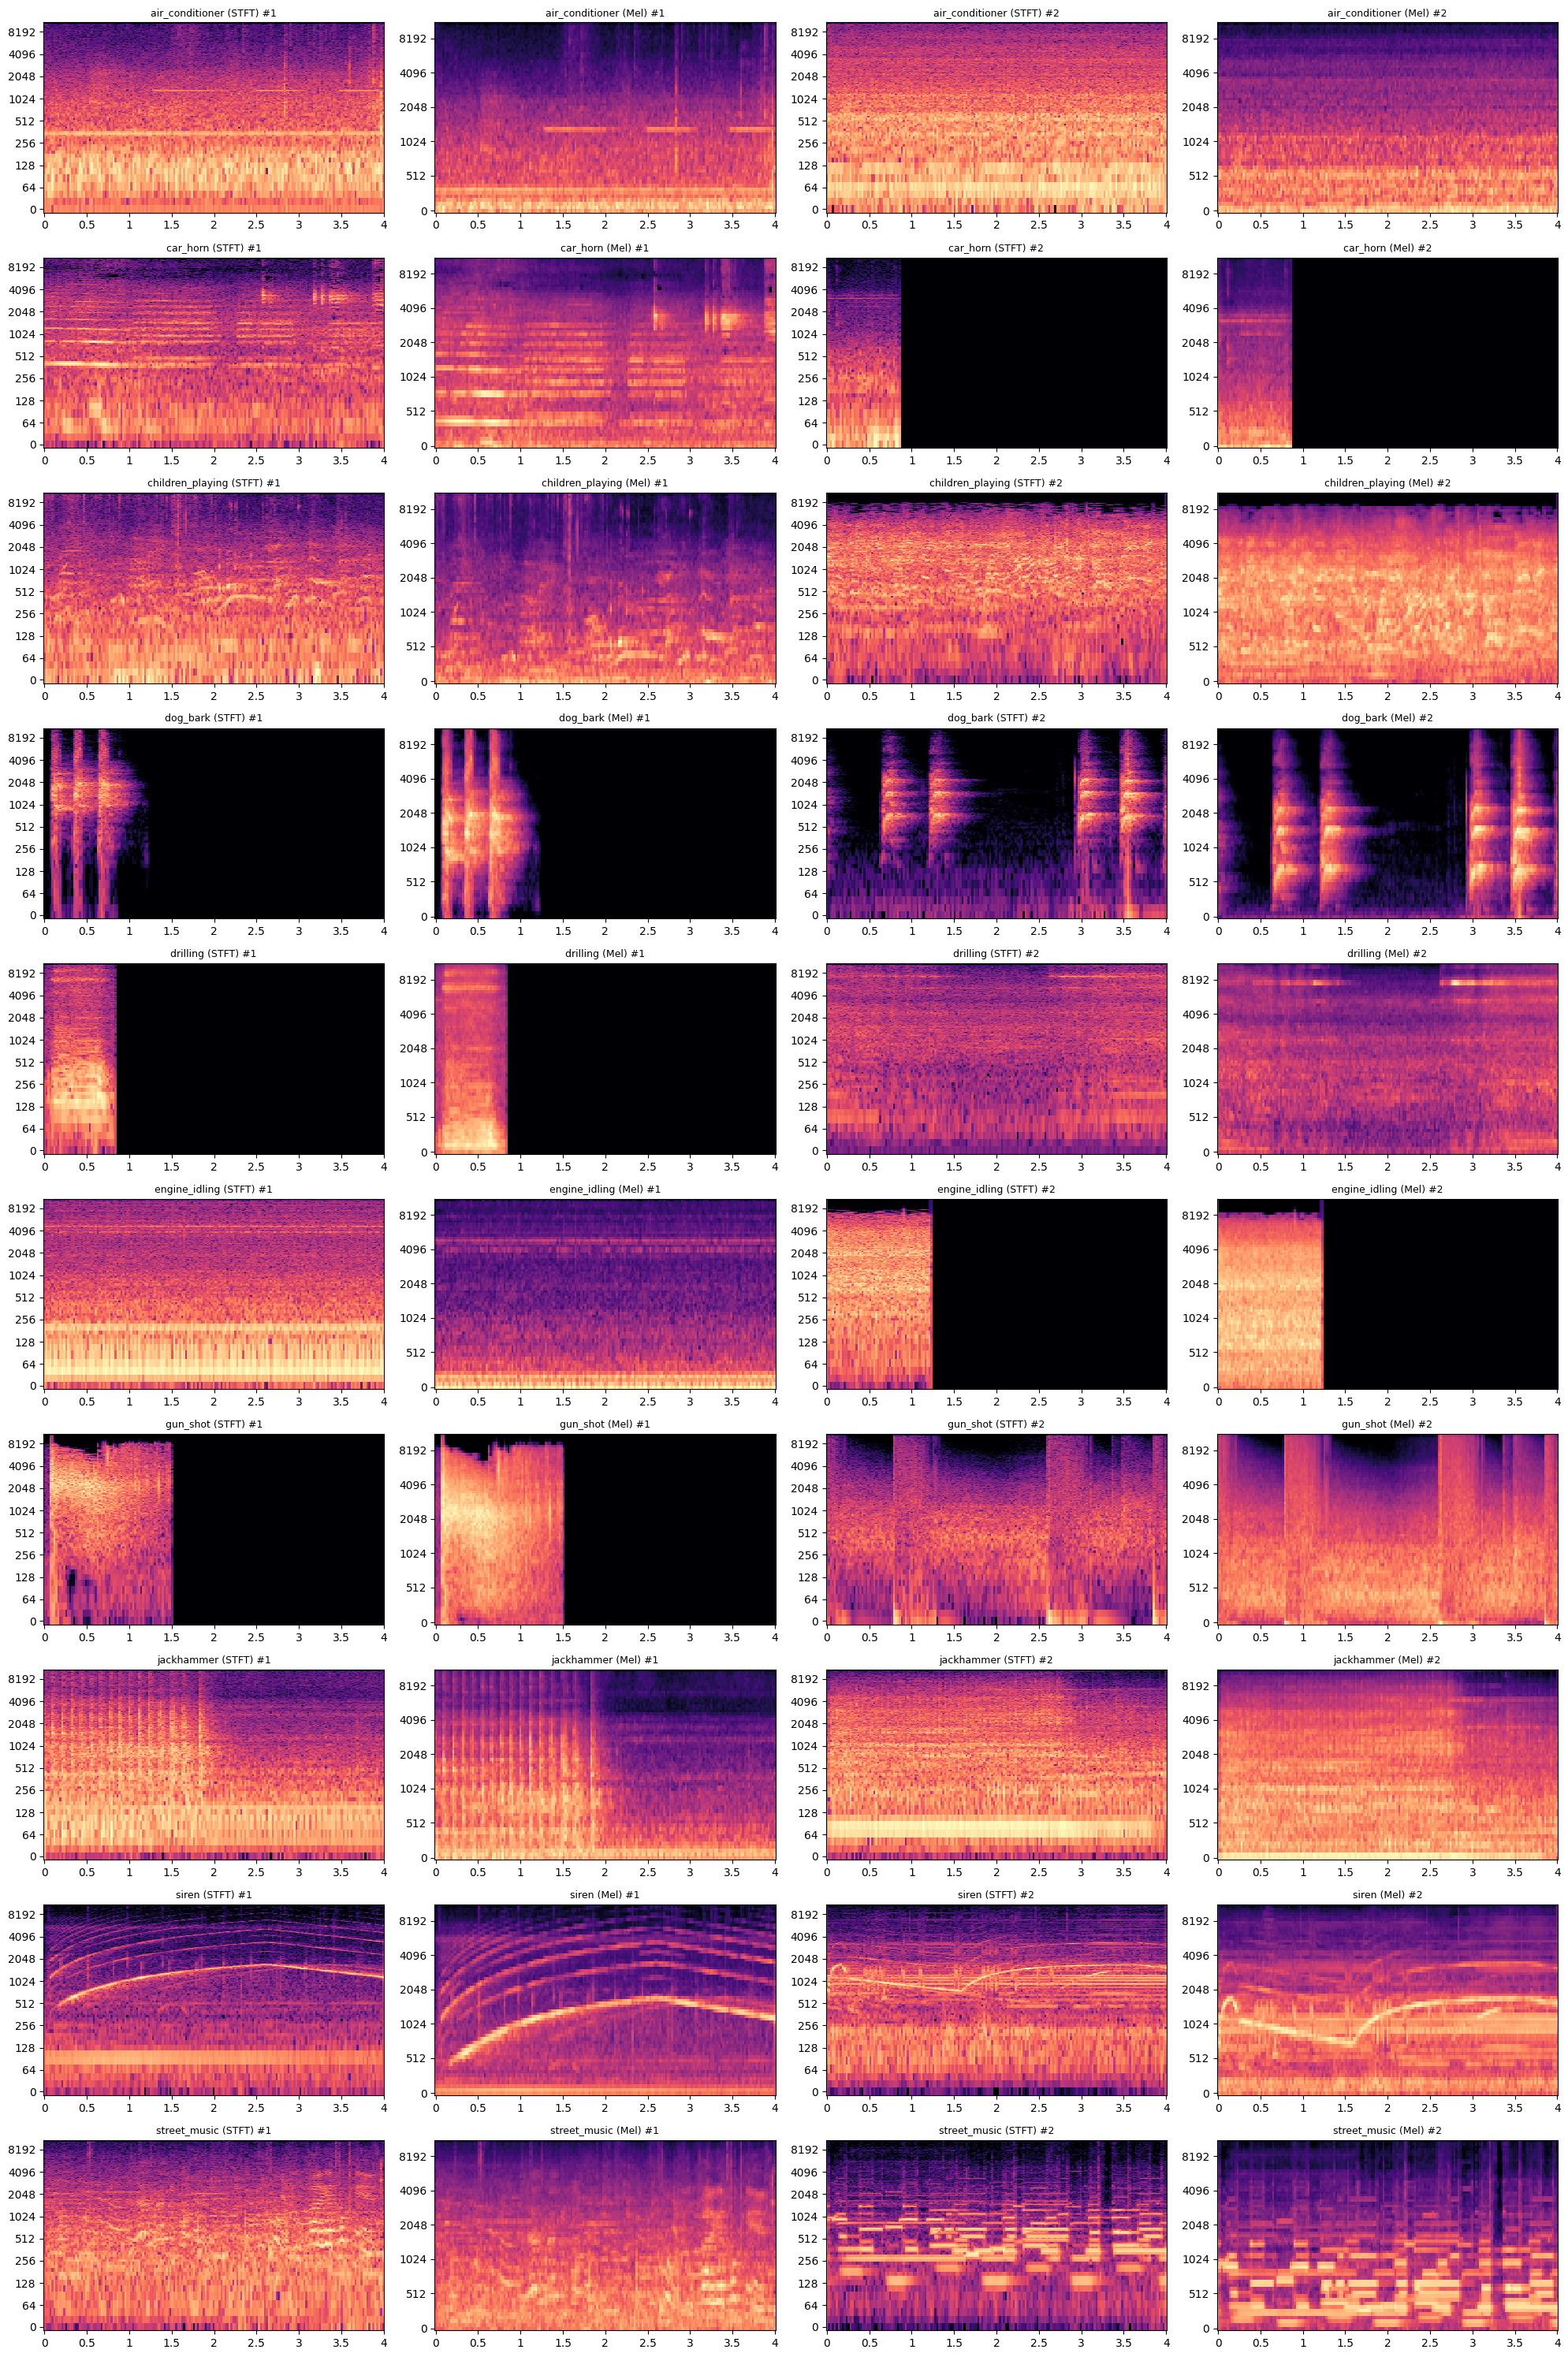

In [ ]:
def get_audio_path(row):
    return AUDIO_DIR / f"fold{row.fold}" / row.slice_file_name

classes = sorted(meta['class'].unique())

fig, axes = plt.subplots(len(classes), 4, figsize=(20, 3 * len(classes)))
for ci, cls in enumerate(classes):
    samples = meta[meta['class'] == cls].sample(2, random_state=SEED)
    for si, (_, row) in enumerate(samples.iterrows()):
        y = load_audio(get_audio_path(row))
        stft_db = compute_stft(y)
        mel_db  = compute_mel(y)

        ax_s = axes[ci, si * 2]
        ax_m = axes[ci, si * 2 + 1]
        librosa.display.specshow(stft_db, sr=SR, hop_length=512,
                                 x_axis='time', y_axis='log', ax=ax_s)
        librosa.display.specshow(mel_db, sr=SR, hop_length=512,
                                 x_axis='time', y_axis='mel', ax=ax_m)
        ax_s.set_title(f"{cls} (STFT) #{si+1}", fontsize=9)
        ax_m.set_title(f"{cls} (Mel) #{si+1}",  fontsize=9)
        ax_s.set(xlabel='', ylabel=''); ax_m.set(xlabel='', ylabel='')

plt.tight_layout()
plt.show()

<h3 style="color:#4285F4;">🔎 Observations</h3>

- **STFT spectrograms** concentrate visible detail in the low-frequency band; the upper rows (high frequencies) are mostly empty.
- **Mel spectrograms** distribute detail more uniformly across the frequency axis, matching how human hearing works.
- **Transient classes** (e.g., `gun_shot`, `dog_bark`) appear as short vertical bursts.
- **Sustained classes** (e.g., `air_conditioner`, `engine_idling`, `jackhammer`) appear as steady horizontal bands.
- **Tonal classes** (e.g., `siren`) show clear rising and falling frequency sweeps.

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  💾 Spectrogram Cache
</h2>

In [ ]:
SPEC_CACHE = Path("/content/spec_cache")

def cache_all(meta, audio_dir, cache_dir, n_fft):
    base = cache_dir / f"nfft_{n_fft}"
    for spec_type in ["stft", "mel"]:
        for fold in range(1, 11):
            (base / spec_type / f"fold{fold}").mkdir(parents=True, exist_ok=True)

    skipped = 0
    for _, row in tqdm(meta.iterrows(), total=len(meta), desc=f"Caching n_fft={n_fft}"):
        src  = audio_dir / f"fold{row.fold}" / row.slice_file_name
        stem = Path(row.slice_file_name).stem
        stft_p = base / "stft" / f"fold{row.fold}" / f"{stem}.npy"
        mel_p  = base / "mel"  / f"fold{row.fold}" / f"{stem}.npy"

        if stft_p.exists() and mel_p.exists():
            skipped += 1
            continue

        y = load_audio(src)
        if not stft_p.exists():
            np.save(stft_p, compute_stft(y, n_fft=n_fft))
        if not mel_p.exists():
            np.save(mel_p, compute_mel(y, n_fft=n_fft))

    print(f"  n_fft={n_fft}: done ({skipped} already cached, skipped)")

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  ⚡  Default Window
</h2>

In [ ]:
cache_all(meta, AUDIO_DIR, SPEC_CACHE, n_fft=1024)

Caching n_fft=1024: 100%|██████████| 8732/8732 [03:22<00:00, 43.03it/s]

  n_fft=1024: done (0 already cached, skipped)


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🗂️  Spectrogram Dataset
</h2>

In [ ]:
class SpecDataset(Dataset):
    """
    Loads pre-cached spectrograms, normalizes, resizes to 224x224,
    replicates to 3 channels, and applies ImageNet normalization.
    """
    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __init__(self, meta_subset, cache_dir, n_fft, spec_type):
        self.meta = meta_subset.reset_index(drop=True)
        self.base = Path(cache_dir) / f"nfft_{n_fft}" / spec_type

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row  = self.meta.iloc[idx]
        stem = Path(row.slice_file_name).stem
        spec = np.load(self.base / f"fold{row.fold}" / f"{stem}.npy")
        spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)

        x = torch.from_numpy(spec).unsqueeze(0).unsqueeze(0)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = x.squeeze(0).repeat(3, 1, 1)
        x = (x - self.IMAGENET_MEAN) / self.IMAGENET_STD
        y = int(row.classID)
        return x, y

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  ✂️ Train || Validation || Test
</h2>

In [ ]:
train_meta = meta[meta['fold'].isin(range(1, 9))]
val_meta   = meta[meta['fold'] == 9]
test_meta  = meta[meta['fold'] == 10]

print(f"Train: {len(train_meta)}  Val: {len(val_meta)}  Test: {len(test_meta)}")

Train: 7079  Val: 816  Test: 837


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🏗️ EfficientNet-B0
</h2>

In [ ]:
def build_model(n_classes=10):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


    for p in m.parameters():
        p.requires_grad = False


    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, n_classes)
    return m

model_check = build_model()
trainable = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_check.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}  ({100*trainable/total:.2f}%)")
del model_check

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s] 


Trainable: 12,810 / Total: 4,020,358  (0.32%)


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🔁 Training and Evaluation
</h2>

In [ ]:
def train_one_run(spec_type, n_fft, epochs=12, lr=1e-3, batch_size=32,
                  patience=4, verbose=True):
    train_ds = SpecDataset(train_meta, SPEC_CACHE, n_fft, spec_type)
    val_ds   = SpecDataset(val_meta,   SPEC_CACHE, n_fft, spec_type)
    test_ds  = SpecDataset(test_meta,  SPEC_CACHE, n_fft, spec_type)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    model = build_model().to(device)
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    criterion = nn.CrossEntropyLoss()

    def evaluate(loader):
        model.eval()
        correct = total_loss = total = 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss   = criterion(logits, y)
                correct    += (logits.argmax(1) == y).sum().item()
                total_loss += loss.item() * y.size(0)
                total      += y.size(0)
        return total_loss / total, correct / total

    best_val_acc = 0.0
    best_state   = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        ep_loss = ep_correct = ep_total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

            ep_loss    += loss.item() * y.size(0)
            ep_correct += (logits.argmax(1) == y).sum().item()
            ep_total   += y.size(0)

        train_loss = ep_loss / ep_total
        train_acc  = ep_correct / ep_total
        val_loss, val_acc = evaluate(val_loader)

        if verbose:
            print(f"  Epoch {epoch+1:2d} | Train Loss {train_loss:.4f} Acc {train_acc:.4f} "
                  f"| Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose: print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    train_loss, train_acc = evaluate(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)
    test_loss,  test_acc  = evaluate(test_loader)

    print(f"  [{spec_type.upper()} n_fft={n_fft}] "
          f"Train {train_acc*100:.2f}% | Val {val_acc*100:.2f}% | Test {test_acc*100:.2f}%")

    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            preds = model(x).argmax(1).cpu().numpy()
            all_preds.extend(preds); all_targets.extend(y.numpy())

    return {
        "spec_type": spec_type, "n_fft": n_fft,
        "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc,
        "preds": np.array(all_preds), "targets": np.array(all_targets),
        "model": model,
    }

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🚀 STFT and Mel || Default
</h2>

In [ ]:
print(">>> STFT @ n_fft=1024")
result_stft_1024 = train_one_run("stft", n_fft=1024)

print("\n>>> Mel @ n_fft=1024")
result_mel_1024  = train_one_run("mel",  n_fft=1024)

print("\nTask 3 — Frozen EfficientNet-B0 results")
print(f"{'Type':<6} {'Train':>8} {'Val':>8} {'Test':>8}")
for r in [result_stft_1024, result_mel_1024]:
    print(f"{r['spec_type'].upper():<6} "
          f"{r['train_acc']*100:>7.2f}% {r['val_acc100:>7.2f}% {r['test_acc']*100:>7.2f}%")

>>> STFT @ n_fft=1024
  Epoch  1 | Train Loss 1.3470 Acc 0.5749 | Val Loss 1.0673 Acc 0.6422
  Epoch  2 | Train Loss 0.9512 Acc 0.6915 | Val Loss 0.9542 Acc 0.6752
  Epoch  3 | Train Loss 0.8405 Acc 0.7286 | Val Loss 0.9334 Acc 0.6752
  Epoch  4 | Train Loss 0.7958 Acc 0.7378 | Val Loss 0.9024 Acc 0.6924
  Epoch  5 | Train Loss 0.7560 Acc 0.7565 | Val Loss 0.8600 Acc 0.7157
  Epoch  6 | Train Loss 0.7228 Acc 0.7606 | Val Loss 0.9180 Acc 0.6850
  Epoch  7 | Train Loss 0.7050 Acc 0.7654 | Val Loss 0.8700 Acc 0.7145
  Epoch  8 | Train Loss 0.6848 Acc 0.7723 | Val Loss 0.8597 Acc 0.7083
  Epoch  9 | Train Loss 0.6872 Acc 0.7668 | Val Loss 0.8483 Acc 0.7218
  Epoch 10 | Train Loss 0.6728 Acc 0.7774 | Val Loss 0.8663 Acc 0.7279
  Epoch 11 | Train Loss 0.6709 Acc 0.7744 | Val Loss 0.8565 Acc 0.7267
  Epoch 12 | Train Loss 0.6520 Acc 0.7793 | Val Loss 0.8407 Acc 0.7279
  [STFT n_fft=1024] Train 84.84% | Val 72.79% | Test 72.28%

>>> Mel @ n_fft=1024
  Epoch  1 | Train Loss 1.3265 Acc 0.5975 | 

<h3 style="color:#4285F4;">💡 Comment</h3>

The **Mel spectrogram outperforms STFT** on test accuracy by roughly 4 percentage points (76.70% vs 72.28%). This is consistent with the perceptual motivation of mel filters — the pretrained EfficientNet-B0 backbone, trained on ImageNet RGB images, extracts features better from inputs where useful information is spread uniformly across the image rather than concentrated in a thin low-frequency band.

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🎯  Confusion Matrices
</h2>

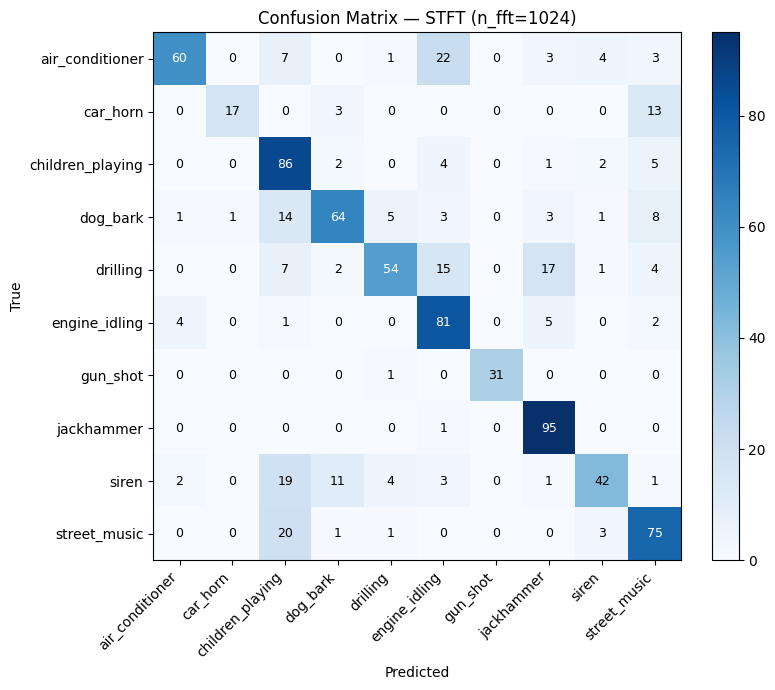

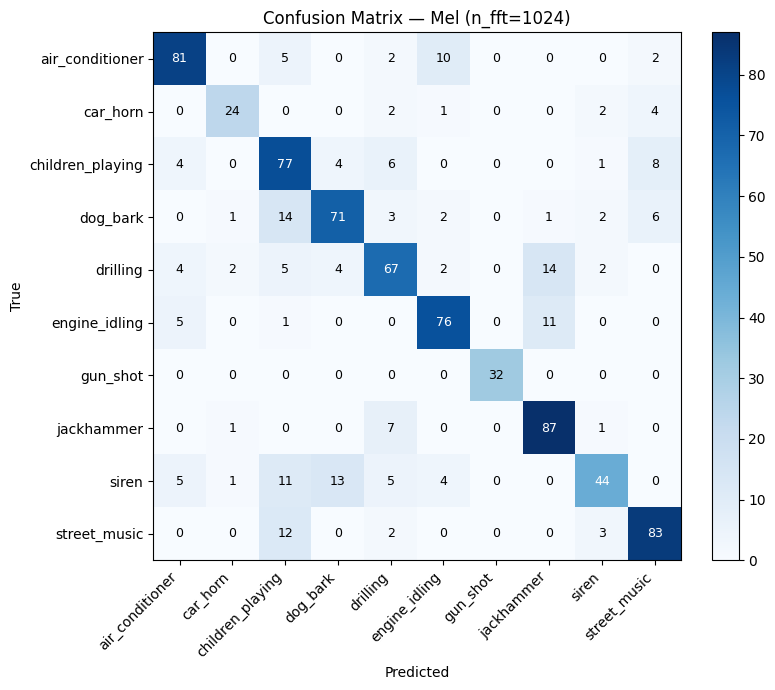

In [ ]:
def plot_confusion(result, classes, title):
    targets, preds = result['targets'], result['preds']
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(targets, preds):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

class_names = [
    'air_conditioner','car_horn','children_playing','dog_bark','drilling',
    'engine_idling','gun_shot','jackhammer','siren','street_music'
]

plot_confusion(result_stft_1024, class_names, "Confusion Matrix — STFT (n_fft=1024)")
plot_confusion(result_mel_1024,  class_names, "Confusion Matrix — Mel (n_fft=1024)")

<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  🪟  Window Size Experiment
</h2>

In [ ]:
window_sizes = [256, 512, 1024, 2048]
all_results  = []

for n_fft in window_sizes:
    print(f"\n=== Caching spectrograms for n_fft={n_fft} ===")
    cache_all(meta, AUDIO_DIR, SPEC_CACHE, n_fft=n_fft)

    print(f"\n=== Training STFT @ n_fft={n_fft} ===")
    r_stft = train_one_run("stft", n_fft=n_fft, verbose=False)

    print(f"\n=== Training Mel @ n_fft={n_fft} ===")
    r_mel  = train_one_run("mel",  n_fft=n_fft, verbose=False)

    all_results.append({"n_fft": n_fft, "stft": r_stft, "mel": r_mel})


=== Caching spectrograms for n_fft=256 ===


Caching n_fft=256: 100%|██████████| 8732/8732 [03:22<00:00, 43.19it/s]


  n_fft=256: done (0 already cached, skipped)

=== Training STFT @ n_fft=256 ===
  [STFT n_fft=256] Train 85.00% | Val 71.57% | Test 74.07%

=== Training Mel @ n_fft=256 ===
  [MEL n_fft=256] Train 81.75% | Val 71.94% | Test 73.95%

=== Caching spectrograms for n_fft=512 ===


Caching n_fft=512: 100%|██████████| 8732/8732 [03:29<00:00, 41.60it/s]


  n_fft=512: done (0 already cached, skipped)

=== Training STFT @ n_fft=512 ===
  [STFT n_fft=512] Train 83.57% | Val 74.26% | Test 72.64%

=== Training Mel @ n_fft=512 ===
  [MEL n_fft=512] Train 82.82% | Val 72.79% | Test 71.92%

=== Caching spectrograms for n_fft=1024 ===


Caching n_fft=1024: 100%|██████████| 8732/8732 [00:01<00:00, 5303.22it/s]


  n_fft=1024: done (8732 already cached, skipped)

=== Training STFT @ n_fft=1024 ===
  [STFT n_fft=1024] Train 86.35% | Val 73.65% | Test 75.03%

=== Training Mel @ n_fft=1024 ===
  [MEL n_fft=1024] Train 85.87% | Val 74.51% | Test 77.54%

=== Caching spectrograms for n_fft=2048 ===


Caching n_fft=2048: 100%|██████████| 8732/8732 [03:36<00:00, 40.40it/s]


  n_fft=2048: done (0 already cached, skipped)

=== Training STFT @ n_fft=2048 ===
  [STFT n_fft=2048] Train 80.18% | Val 70.47% | Test 68.94%

=== Training Mel @ n_fft=2048 ===
  [MEL n_fft=2048] Train 88.26% | Val 74.88% | Test 76.70%


<h2 style="color:#4285F4; border-bottom: 2px solid #4285F4; padding-bottom: 8px;">
  📊 Summary
</h2>

In [ ]:
print("Task 4 — Window Size Experiment")
print(f"{'n_fft':>6} | {'STFT Train':>11} {'STFT Test':>10} | {'Mel Train':>10} {'Mel Test':>10}")
print("-" * 60)
for r in all_results:
    print(f"{r['n_fft']:>6} | "
          f"{r['stft']['train_acc']*100:>10.2f}% {r['stft']['test_acc']*100:>9.2f}% | "
          f"{r['mel']['train_acc']*100:>9.2f}% {r['mel']['test_acc']*100:>9.2f}%")

print("\nSpectrogram shape per n_fft (4-second clip @ 22.05 kHz):")
print(f"{'n_fft':>6} | {'STFT (F x T)':>20} | {'Mel (F x T)':>15}")
for n_fft in window_sizes:
    hop = n_fft // 2
    n_frames = (TARGET_LEN - n_fft) // hop + 1
    n_freq   = n_fft // 2 + 1
    print(f"{n_fft:>6} | {f'{n_freq} x {n_frames}':>20} | {f'{N_MELS} x {n_frames}':>15}")

def best_n_fft(spec_key):
    return max(all_results, key=lambda r: r[spec_key]['test_acc'])
print(f"\nBest STFT n_fft: {best_n_fft('stft')['n_fft']} "
      f"({best_n_fft('stft')['stft']['test_acc']*100:.2f}% test acc)")
print(f"Best Mel  n_fft: {best_n_fft('mel')['n_fft']} "
      f"({best_n_fft('mel')['mel']['test_acc']*100:.2f}% test acc)")

Task 4 — Window Size Experiment
 n_fft |  STFT Train  STFT Test |  Mel Train   Mel Test
------------------------------------------------------------
   256 |      85.00%     74.07% |     81.75%     73.95%
   512 |      83.57%     72.64% |     82.82%     71.92%
  1024 |      86.35%     75.03% |     85.87%     77.54%
  2048 |      80.18%     68.94% |     88.26%     76.70%

Spectrogram shape per n_fft (4-second clip @ 22.05 kHz):
 n_fft |         STFT (F x T) |     Mel (F x T)
   256 |            129 x 688 |        64 x 688
   512 |            257 x 343 |        64 x 343
  1024 |            513 x 171 |        64 x 171
  2048 |            1025 x 85 |         64 x 85

Best STFT n_fft: 1024 (75.03% test acc)
Best Mel  n_fft: 1024 (77.54% test acc)
